In [6]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
from matplotlib import pyplot as plt
import skrf as rf

pjoin = os.path.join
pbase = os.path.basename

%load_ext autoreload
%autoreload 2


# import relevant classes from highz_exp
from highz_exp.load_trc import TraceLoader
from highz_exp.spec_class import Spectrum
from highz_exp.s_params import S_Params
from highz_exp import plotter
from highz_exp.circuit_model import LNAModel
from highz_exp.reflection_proc import reflection_coefficient

cmap = plt.get_cmap('Accent')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
data_path = os.path.expanduser("~/Desktop/High-Z/long_cable")
trc_file = pjoin(data_path, "99_62_OHM.trc")

loader = TraceLoader(trc_file)

trace = loader.load_trace(1)
ohm_99 = Spectrum(trace[0], trace[1], name='Long Cable - 99 Ohm', colorcode='deepskyblue').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(2)
ohm_62 = Spectrum(trace[0], trace[1], name='Long Cable - 62 Ohm', colorcode='lightcoral').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

trc_file = pjoin(data_path, "699_885OHM.trc")

loader = TraceLoader(trc_file)

trace = loader.load_trace(1)
ohm_699 = Spectrum(trace[0], trace[1], name='8" Cable - 699 Ohm', colorcode='maroon').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(2)
ohm_885 = Spectrum(trace[0], trace[1], name='8" Cable - 885 Ohm', colorcode='lightseagreen').unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(3)
ohm_351 = Spectrum(trace[0], trace[1], name='8" Cable - 351 Ohm', colorcode=cmap(0)).unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
trace = loader.load_trace(4)
ohm_2413 = Spectrum(trace[0], trace[1], name='8" Cable - 2413 Ohm', colorcode=cmap(1)).unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

LNA_SMatrix = S_Params(pjoin(data_path, "LNA12.S2P"), labels='LNA S12')

LNA_SMatrix.resample(ohm_99.f)
for spec in [ohm_99, ohm_62, ohm_699, ohm_885, ohm_351, ohm_2413]:
    spec.resample(LNA_SMatrix.ntwk_dict['LNA S12'].f)
    spec.s = spec.s / (np.abs(LNA_SMatrix.ntwk_dict['LNA S12'].s[:, 1, 0])**2)

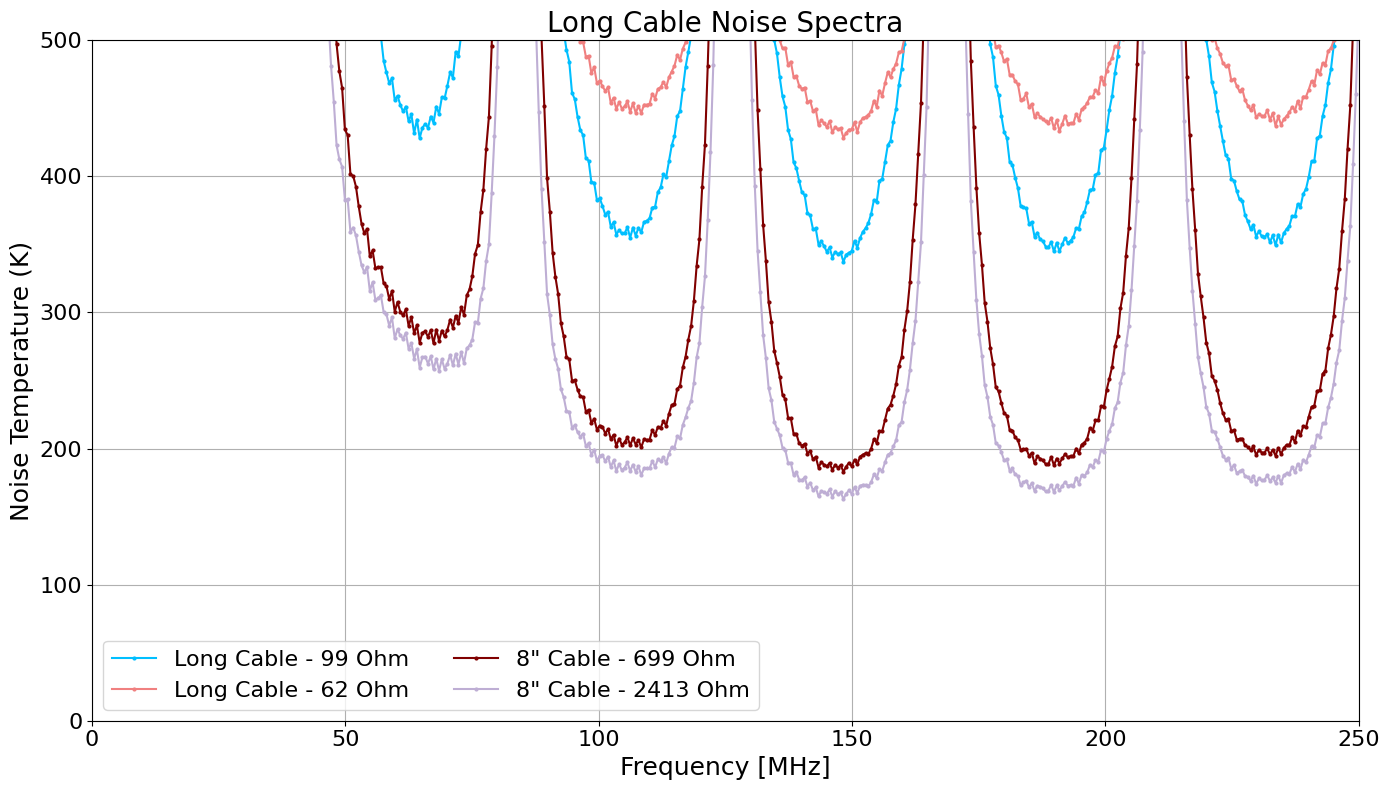

In [8]:
plotter.plot_spectra([ohm_99, ohm_62, ohm_699, ohm_2413], title='Long Cable Noise Spectra', freq_range=(0, 250),
                     ylabel='Noise Temperature (K)', y_range=(0, 500), marker='o', ms=2)

In [9]:
S11s = S_Params(s_params_files=[pjoin(data_path, fn) 
    for fn in ['62OHM.S1P', '99OHM.S1P', '351OHM.S1P', '699OHM.S1P', 'LNA11.S1P']], 
    labels=['62 Ohm', '99 Ohm', '351 Ohm', '699 Ohm', 'LNA'], 
    colorcode=['lightcoral', 'deepskyblue', 'mediumseagreen', 'maroon', 'orange'])

S11s.resample(ohm_99.f)
reflect_ntwk = reflection_coefficient(S11s.ntwk_dict['62 Ohm'], LNA_SMatrix.ntwk_dict['LNA S12'])

In [33]:
# frequency axis
chosen_f = ohm_99.f
d = 2.4384 # meters
z_0 = 50
r_l = 99
z_in = S11s.ntwk_dict['99 Ohm'].z[:, 0, 0]
gamma_load = rf.tlineFunctions.zl_2_Gamma0(z_0, r_l)

gamma_in =  rf.tlineFunctions.zl_2_Gamma0(z_0, S11s.ntwk_dict['99 Ohm'].z[:, 0, 0]) # at input
prop_cst = rf.tlineFunctions.reflection_coefficient_2_propagation_constant(gamma_in, gamma_load, d)

In [42]:
r_l_test = 62.3
test_impd = rf.tlineFunctions.zl_2_zin(z_0, r_l_test, theta=prop_cst * d)

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

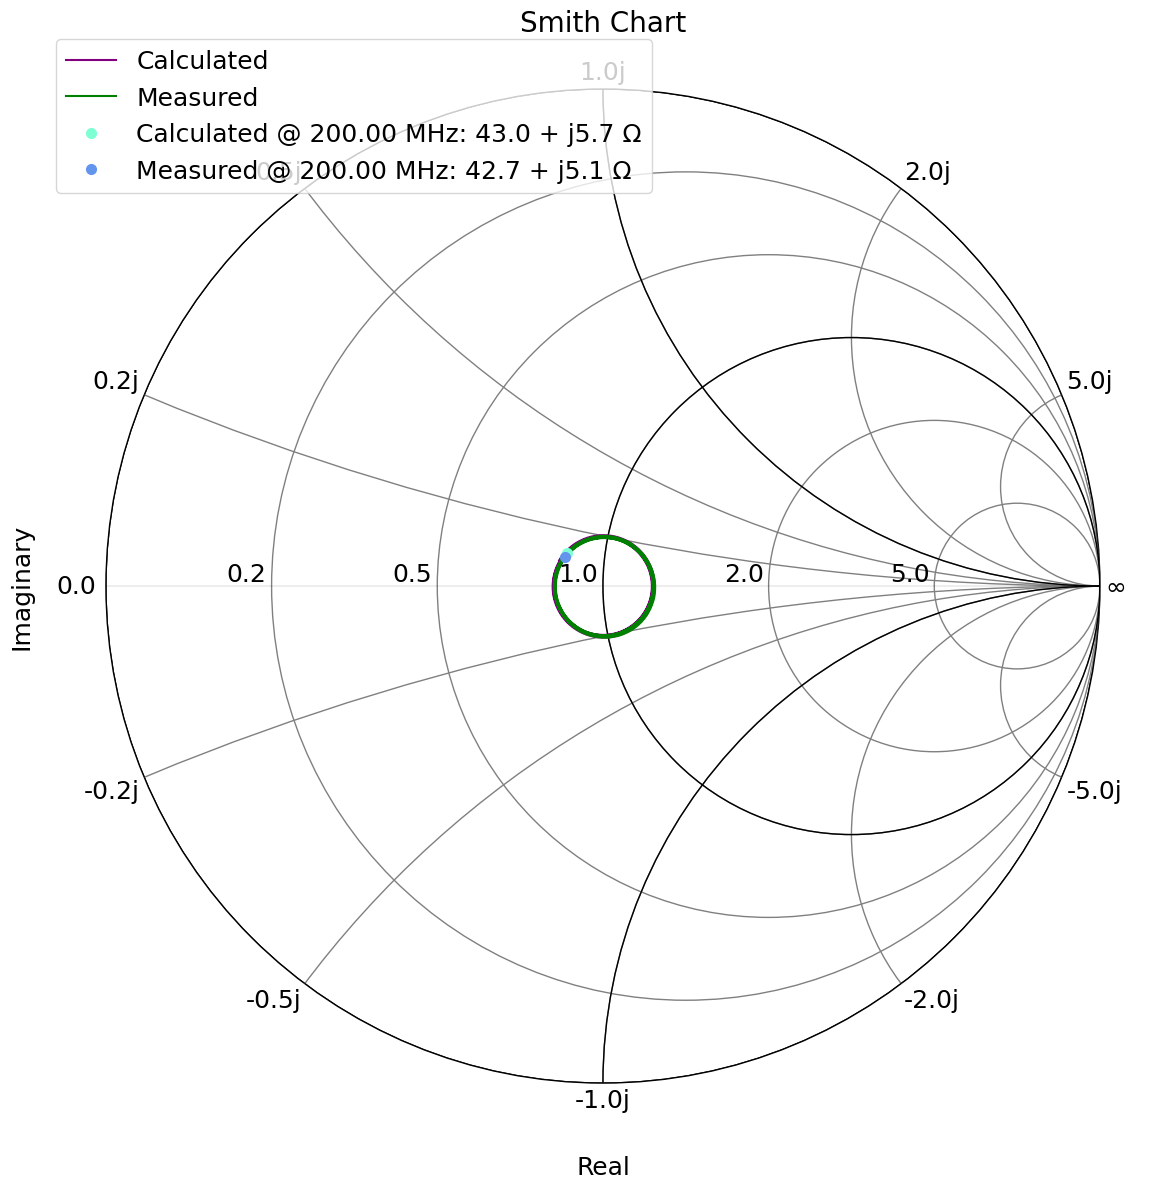

In [43]:
test_ntwk = rf.Network(f=chosen_f, z0=z_0, z=test_impd[:, np.newaxis, np.newaxis])
comparison = S_Params(ntwk_dict={'Calculated': test_ntwk, 'Measured': S11s.ntwk_dict['62 Ohm']}, 
                      colorcode=['purple', 'green'])
comparison.plot_smith_chart(marker_freqs=[200e6])

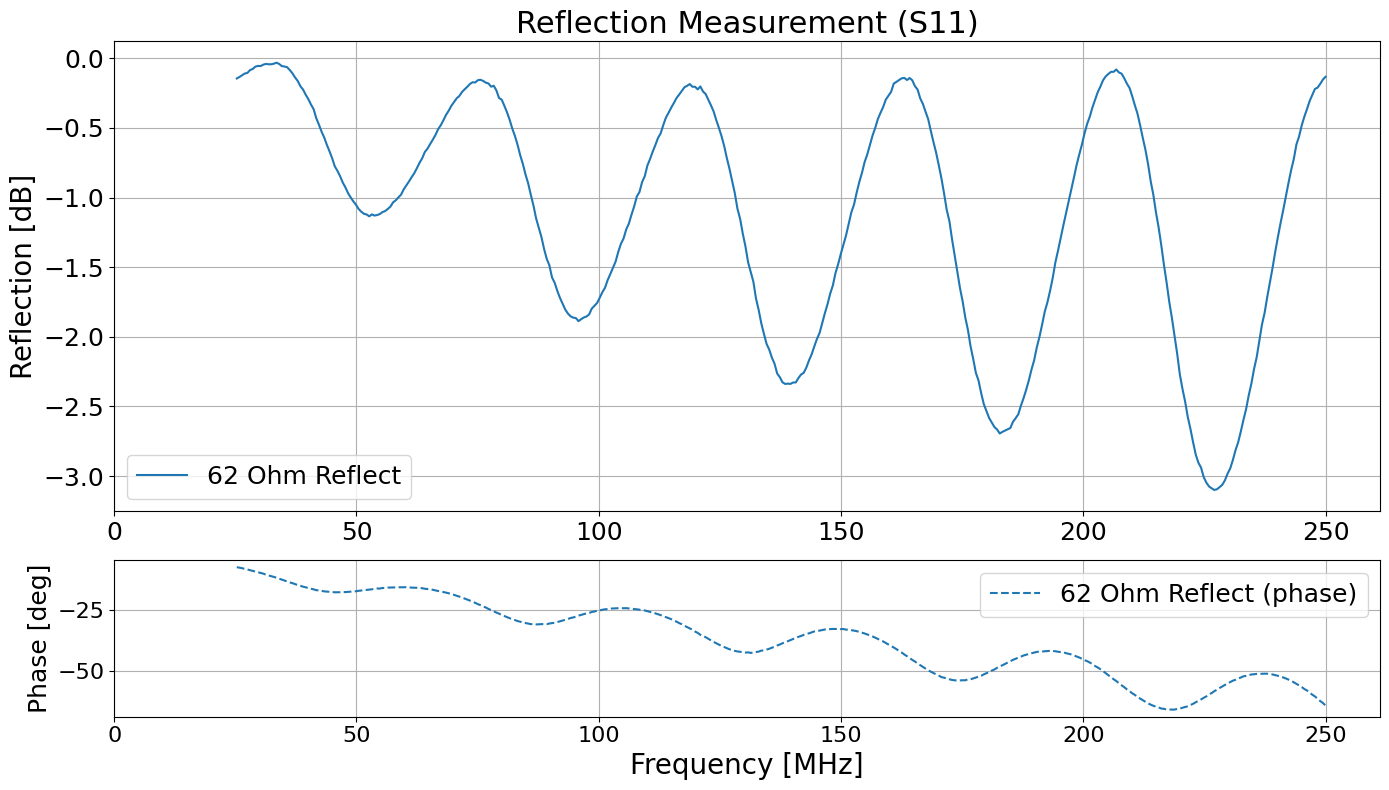

In [ ]:

reflect = S_Params(ntwk_dict={'62 Ohm Reflect': reflect_ntwk}, labels='62 Ohm Reflect', colorcode=['lightcoral'])
reflect.plot_reflection_loss(show_phase=True)
# ant_path = os.path.expanduser("~/Desktop/High-Z/woRelays_wRadials")
# ant_colorcode = {'Ant 1': 'maroon', 'Ant 2': 'olive', 'Ant 3': 'teal', 'Ant 4': 'navy'}
# ant_s11 = S_Params(s_params_files=[pjoin(ant_path, f'Ant{n}.s1p') for n in range(1, 5)],
#                    labels=[f'Ant {n}' for n in range(1, 5)], 
#                    colorcode=ant_colorcode)

In [32]:
def Fmatrix_from_specs(list_of_specs, RBW):
    n_f = len(list_of_specs[0].f)
    n_s = len(list_of_specs)
    F_matrix = np.zeros((n_f, n_s))
    for i, spec in enumerate(list_of_specs):
        spec_T = spec.unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=RBW).s
        F_matrix[:, i] = spec_T
    return F_matrix

In [33]:
F_matrix = Fmatrix_from_specs([ohm_62, ohm_99, ohm_699, ohm_885], RBW=1e6)

/Users/yuntongzhou/Desktop/DevSpace/Highz-EXP/src/highz_exp/unit_convert.py:21: RuntimeWarning: overflow encountered in power
  return 10**(spectrum/10)
/Users/yuntongzhou/Desktop/DevSpace/Highz-EXP/src/highz_exp/unit_convert.py:30: RuntimeWarning: overflow encountered in divide
  return dbm_to_milliwatt(spectrum) * 10**(-3) / channel_width / k_B


In [ ]:


resample_axis = np.arange(25e6, 250e6, 0.5e6)
S11s.interpolate_all(resample_axis)
ant_s11.interpolate_all(resample_axis)


{'Ant 1': 1-Port Network: 'Ant1',  25000000.0-249500000.0 Hz, 450 pts, z0=[50.+0.j],
 'Ant 2': 1-Port Network: 'Ant2',  25000000.0-249500000.0 Hz, 450 pts, z0=[50.+0.j],
 'Ant 3': 1-Port Network: 'Ant3',  25000000.0-249500000.0 Hz, 450 pts, z0=[50.+0.j],
 'Ant 4': 1-Port Network: 'Ant4',  25000000.0-249500000.0 Hz, 450 pts, z0=[50.+0.j]}

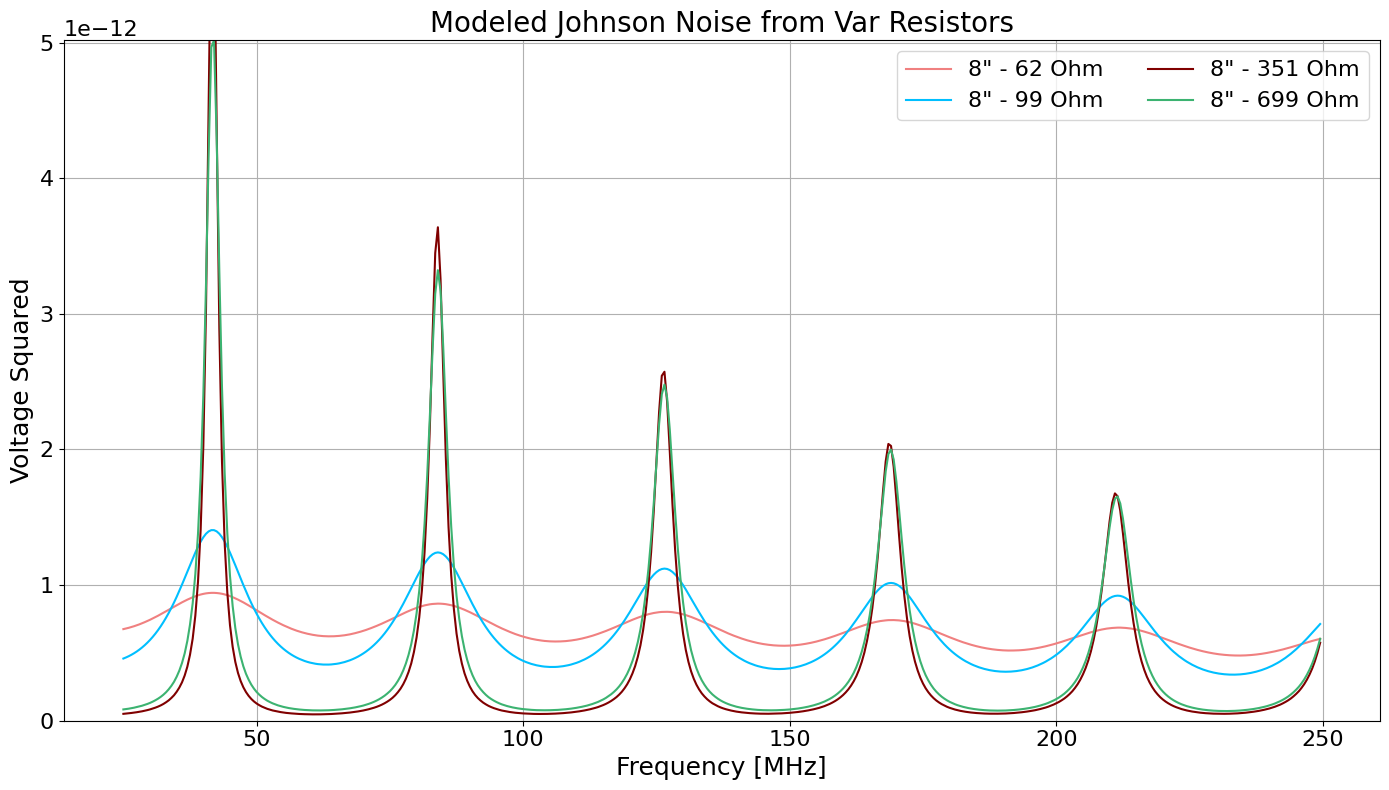

In [21]:
V_62 = LNAModel.V_delivered_from_s11(S11s.ntwk_dict['62 Ohm'], S11s.ntwk_dict['LNA'], 
                                         T_source=300, B=1e6, name='8" - 62 Ohm', colorcode='lightcoral')
V_99 = LNAModel.V_delivered_from_s11(S11s.ntwk_dict['99 Ohm'], S11s.ntwk_dict['LNA'], 
                                         T_source=300, B=1e6, name='8" - 99 Ohm', colorcode='deepskyblue')
V_351 = LNAModel.V_delivered_from_s11(S11s.ntwk_dict['351 Ohm'], S11s.ntwk_dict['LNA'],
                                        T_source=300, B=1e6, name='8" - 351 Ohm', colorcode='maroon')
V_699 = LNAModel.V_delivered_from_s11(S11s.ntwk_dict['699 Ohm'], S11s.ntwk_dict['LNA'], 
        T_source=300, B=1e6, name='8" - 699 Ohm', colorcode='mediumseagreen')
plotter.plot_spectra([V_62, V_99, V_351, V_699], title='Modeled Johnson Noise from Var Resistors',
        ylabel='Voltage Squared', y_range=(0, None))

In [34]:
T_62 = LNAModel.T_out_from_noise_src(S11s.ntwk_dict['62 Ohm'], S11s.ntwk_dict['LNA'], 
                                     T_src=300, name='8" cable - 62 Ohm', colorcode='lightcoral')
T_351 = LNAModel.T_out_from_noise_src(S11s.ntwk_dict['351 Ohm'], S11s.ntwk_dict['LNA'],
                                     T_src=300, name='8" cable - 351 Ohm', colorcode='maroon')
T_699 = LNAModel.T_out_from_noise_src(S11s.ntwk_dict['699 Ohm'], S11s.ntwk_dict['LNA'], 
                                     T_src=300, name='8" cable - 699 Ohm', colorcode='mediumseagreen')
T_99 = LNAModel.T_out_from_noise_src(S11s.ntwk_dict['99 Ohm'], S11s.ntwk_dict['LNA'], 
                                     T_src=300, name='8" cable - 99 Ohm', colorcode='deepskyblue')

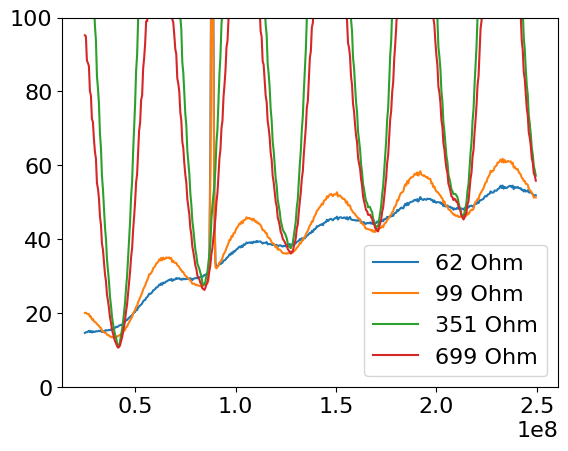

In [35]:
plt.plot(resample_axis, ohm_62.resample(resample_axis).s/T_62.s, label='62 Ohm')
plt.plot(resample_axis, ohm_99.resample(resample_axis).s/T_99.s, label='99 Ohm')
plt.plot(resample_axis, ohm_351.resample(resample_axis).s/T_351.s, label='351 Ohm')
plt.plot(resample_axis, ohm_699.resample(resample_axis).s/T_699.s, label='699 Ohm')
plt.ylim(0, 100)
plt.legend()

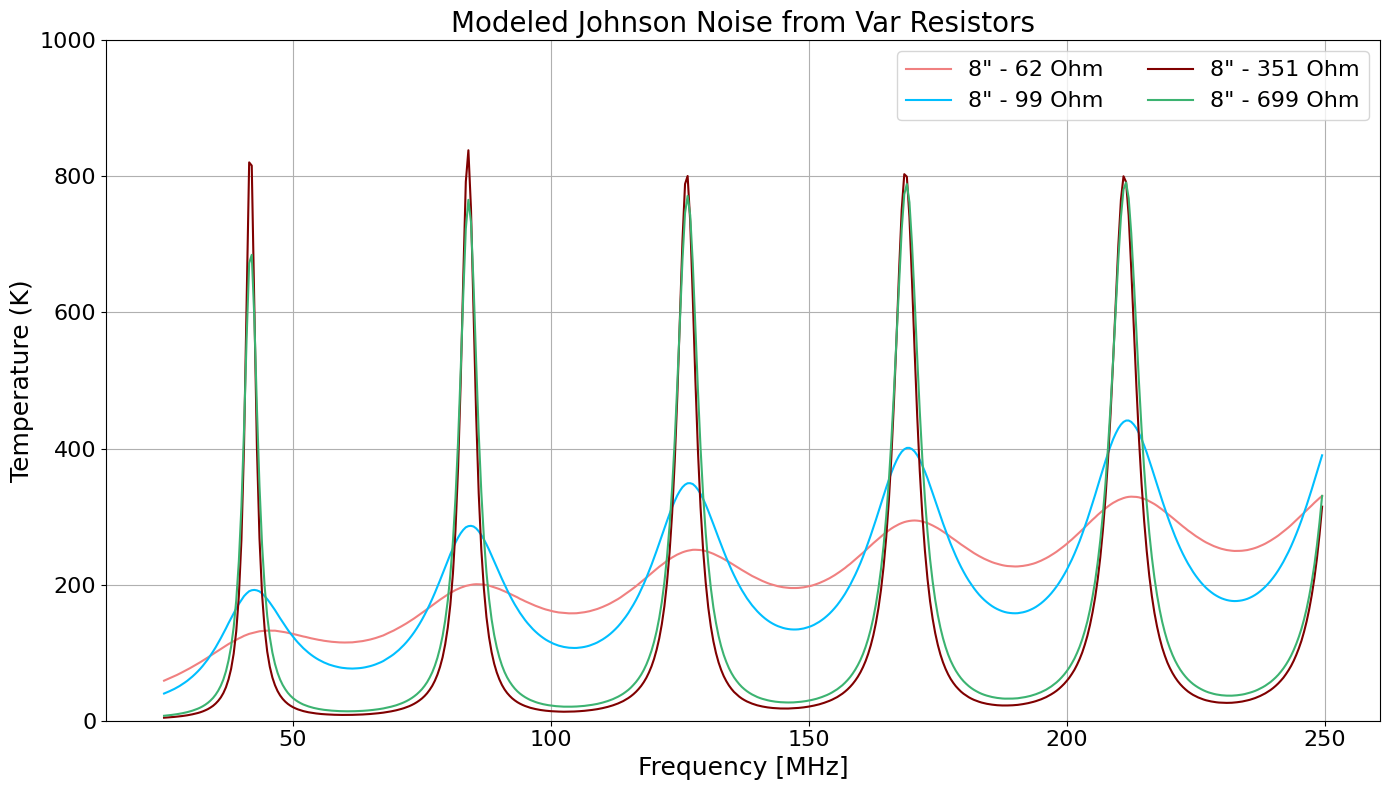

In [22]:
T_62 = LNAModel.T_delivered_from_s11(S11s.ntwk_dict['62 Ohm'], S11s.ntwk_dict['LNA'], 
                                         T_source=300, B=1e6, name='8" - 62 Ohm', colorcode='lightcoral')
T_99 = LNAModel.T_delivered_from_s11(S11s.ntwk_dict['99 Ohm'], S11s.ntwk_dict['LNA'], 
                                         T_source=300, B=1e6, name='8" - 99 Ohm', colorcode='deepskyblue')
T_351 = LNAModel.T_delivered_from_s11(S11s.ntwk_dict['351 Ohm'], S11s.ntwk_dict['LNA'],
                                        T_source=300, B=1e6, name='8" - 351 Ohm', colorcode='maroon')
T_699 = LNAModel.T_delivered_from_s11(S11s.ntwk_dict['699 Ohm'], S11s.ntwk_dict['LNA'], 
        T_source=300, B=1e6, name='8" - 699 Ohm', colorcode='mediumseagreen')
plotter.plot_spectra([T_62, T_99, T_351, T_699], title='Modeled Johnson Noise from Var Resistors',
        ylabel='Temperature (K)', y_range=(0, 1000))

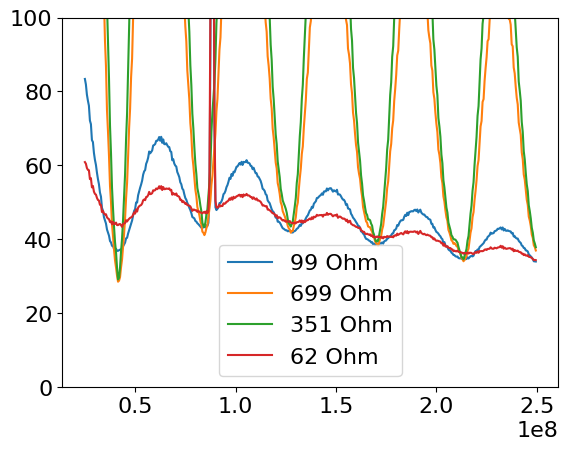

In [26]:
plt.plot(resample_axis, ohm_99.resample(resample_axis).s/T_99.s, label='99 Ohm')
plt.plot(resample_axis, ohm_699.resample(resample_axis).s/T_699.s, label='699 Ohm')
plt.plot(resample_axis, ohm_351.resample(resample_axis).s/T_351.s, label='351 Ohm')
plt.plot(resample_axis, ohm_62.resample(resample_axis).s/T_62.s, label='62 Ohm')
plt.ylim(0, 100)
plt.legend()

In [ ]:
def match_s11(s11, target_s11, tolerance=0.1, freq_window=3):
    """
    Parameters:
    s11 (rf.Network): The S11 parameters of the antenna to be matched.
    target_s11 (rf.Network): The target S11 parameters representing the desired impedance match.
    tolerance (float): The tolerance for considering a match.
    
    Returns:
    dict: A dictionary containing the best match frequency, S11 value, and the corresponding impedance.
    """ 
    
    match_mask = np.abs((np.real(s11.z[:, 0, 0]) - np.real(target_s11.z[:, 0, 0])) / np.real(target_s11.z[:, 0, 0])) < tolerance
    match_mask &= np.abs((np.imag(s11.z[:, 0, 0]) - np.imag(target_s11.z[:, 0, 0])) / np.imag(target_s11.z[:, 0, 0])) < tolerance

    matched_freqs = s11.f[match_mask]
    matched_s11_values = s11.s[match_mask, 0, 0]
    

    ntwk = rf.Network(f=matched_freqs, s=matched_s11_values[:, np.newaxis, np.newaxis])
    target_ntwk = rf.Network(f=matched_freqs, s=target_s11.s[match_mask])
    
    return ntwk, target_ntwk

In [69]:
ntwk, ant_ntwk = match_s11(S11s.ntwk_dict['99 Ohm'], ant_s11.ntwk_dict['Ant 1'], tolerance=0.2)
matched_ant1 = S_Params(ntwk_dict={'Ant 1': ant_ntwk, 'Matched from cable': ntwk})

ntwk, ant_ntwk = match_s11(S11s.ntwk_dict['62 Ohm'], ant_s11.ntwk_dict['Ant 1'], tolerance=0.2)
matched_ant1_62 = S_Params(ntwk_dict={'Ant 1': ant_ntwk, 'Matched from cable': ntwk})

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

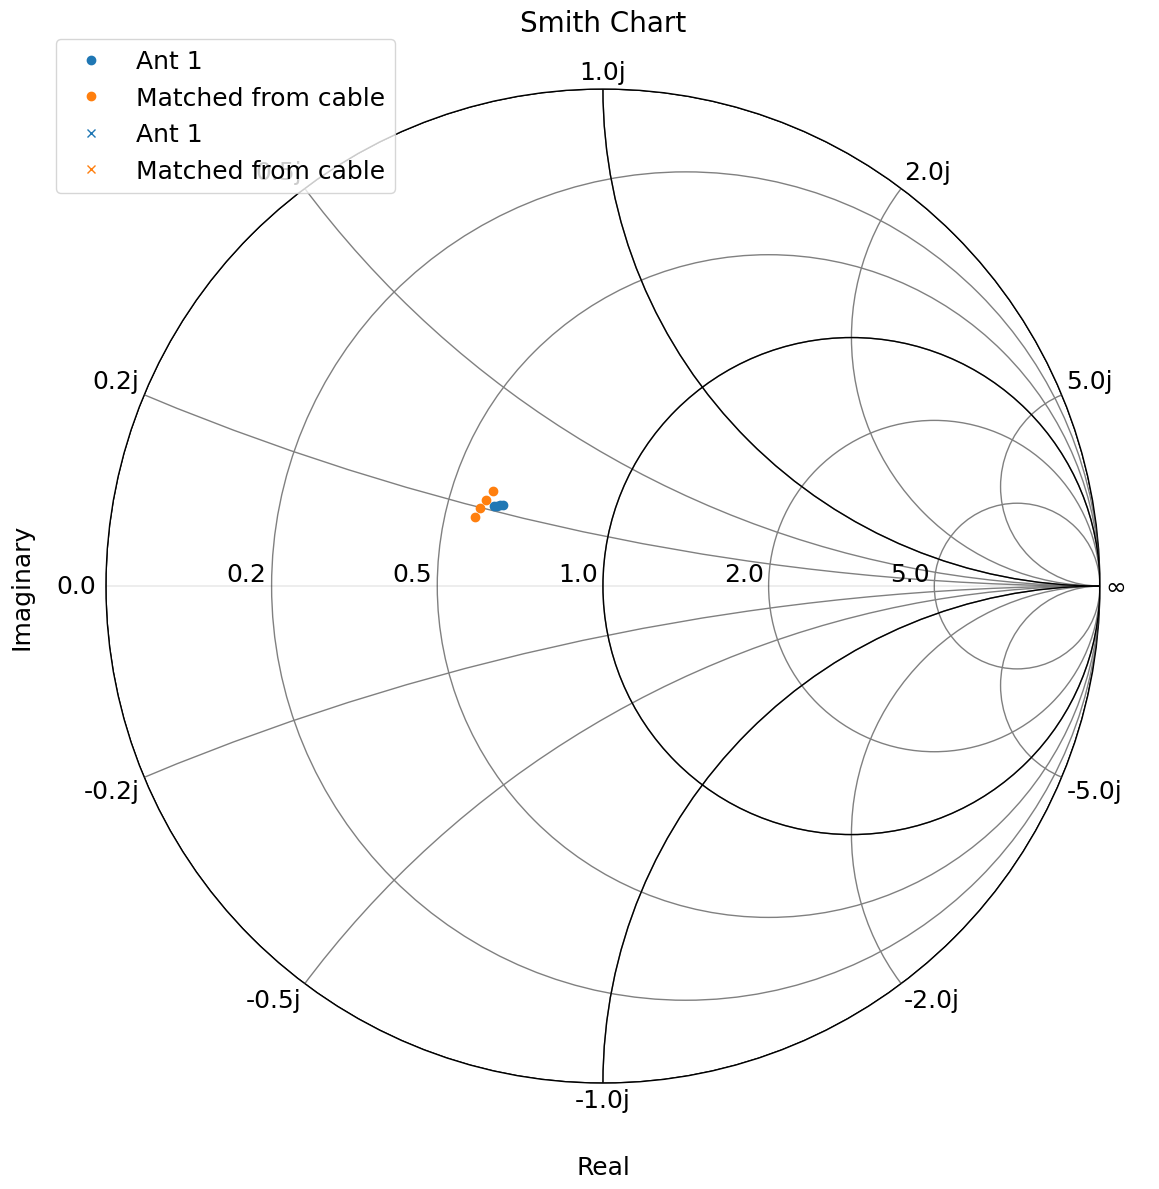

In [70]:
fig, ax = matched_ant1.plot_smith_chart(ls='', marker='o')
matched_ant1_62.plot_smith_chart(ls='', marker='x', fig=fig, ax=ax)

In [38]:
reflection_S11s = S_Params(ntwk_dict={label: reflection_proc.LNA_total_reflection(S11s.ntwk_dict[label], S11s.ntwk_dict['LNA']) 
                    for label in ['62 Ohm', '99 Ohm']}, colorcode={'62 Ohm': 'lightcoral', '99 Ohm': 'deepskyblue'})

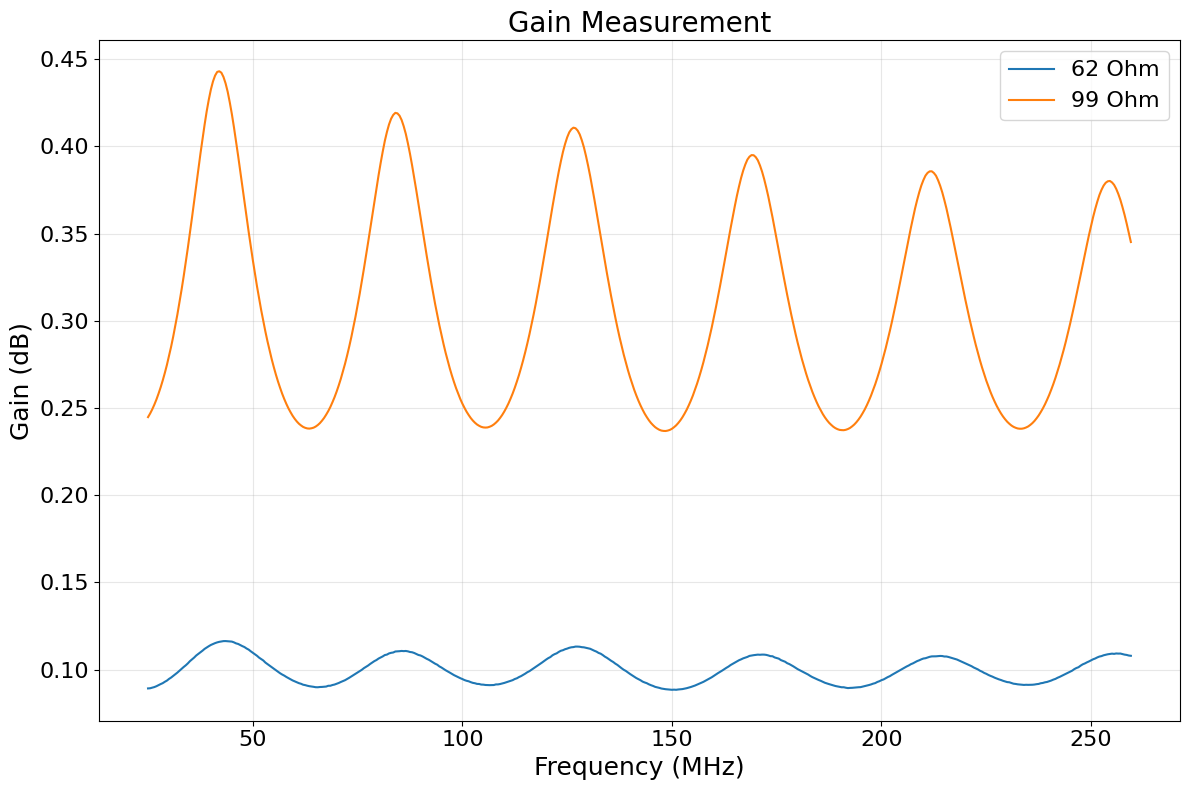

In [41]:
reflection_S11s.plot_gain(scale='linear')

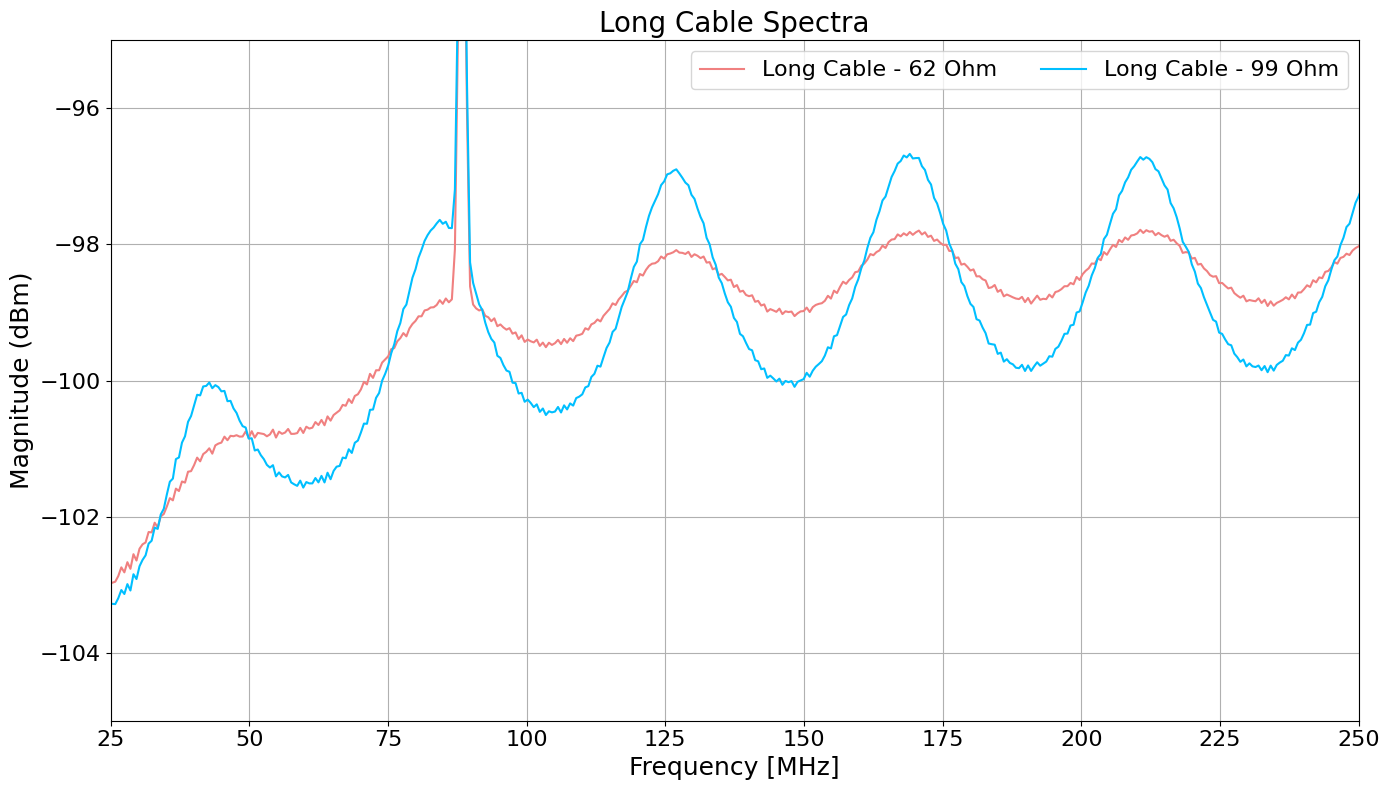

In [21]:
plotter.plot_spectra([ohm_62, ohm_99], freq_range=(25, 250), title="Long Cable Spectra", 
                     ylabel="Magnitude (dBm)", y_range=(-105, -95))